# Hospital Readmission Prediction Using Elastic Net Regularized Logistic Regression

### Machine Learning Project — A.Y. 2026–27

**Team**
- 2500031613 — Uppalapati Moksha Ratna
- 252003004 — Sinde Vedhanth
- 2520030025 — Vootla Hemanth

**Guide:** Gaddam Ravindra Babu  
**Department:** CSE  
**Dataset:** UCI Diabetes 130-US Hospitals Dataset

---

### Project Objective

This notebook predicts whether a patient is likely to be readmitted using **Elastic Net Regularized Logistic Regression**.

The workflow follows the project abstract:

**Data Analytics → EDA → Preprocessing → Logistic Regression → Elastic Net Logistic Regression → Hyperparameter Tuning → Evaluation → Feature Analysis → Final Prediction**

The target column in the cleaned dataset is `readmitted`, where:

- `0` = not readmitted
- `1` = readmitted

## 1. Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Upload and Load the Cleaned Dataset

Upload the Excel file containing the cleaned dataset.

The notebook automatically looks for the `Cleaned_Dataset_FULL` sheet. If a CSV is uploaded instead, it loads the CSV directly.

In [ ]:
from google.colab import files

uploaded = files.upload()

uploaded_name = list(uploaded.keys())[0]
print("Uploaded file:", uploaded_name)

if uploaded_name.lower().endswith((".xlsx", ".xls")):
    excel_file = pd.ExcelFile(uploaded_name)
    print("Available sheets:", excel_file.sheet_names)

    if "Cleaned_Dataset_FULL" in excel_file.sheet_names:
        df = pd.read_excel(uploaded_name, sheet_name="Cleaned_Dataset_FULL")
        print("Loaded sheet: Cleaned_Dataset_FULL")
    else:
        # Fallback: load the first sheet if the expected cleaned sheet is unavailable
        df = pd.read_excel(uploaded_name, sheet_name=0)
        print("Expected cleaned sheet not found. Loaded first sheet:", excel_file.sheet_names[0])

elif uploaded_name.lower().endswith(".csv"):
    df = pd.read_csv(uploaded_name)
    print("Loaded CSV dataset.")
else:
    raise ValueError("Please upload an Excel (.xlsx/.xls) or CSV (.csv) dataset.")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

## 3. Dataset Overview

In [ ]:
print("=" * 60)
print("FIRST 5 RECORDS")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n" + "=" * 60)
print("COLUMN NAMES")
print("=" * 60)
print(df.columns.tolist())

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes)

## 4. Data Quality Analysis

In [ ]:
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
display(missing[missing > 0].sort_values(ascending=False).to_frame("Missing_Values"))

print("Total missing values:", int(df.isnull().sum().sum()))

print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)
print("Duplicate rows:", int(df.duplicated().sum()))

print("\n" + "=" * 60)
print("UNIQUE VALUES")
print("=" * 60)
unique_df = pd.DataFrame({
    "Column": df.columns,
    "Unique_Values": [df[c].nunique(dropna=False) for c in df.columns],
    "Data_Type": [str(df[c].dtype) for c in df.columns]
})
display(unique_df)

## 5. Statistical Summary

In [ ]:
print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
display(df.describe(include="all").T)

## 6. Target Variable Analysis

The target is `readmitted`.

This is a binary classification task:
- `0` → No readmission
- `1` → Readmission

In [ ]:
target = "readmitted"

if target not in df.columns:
    raise ValueError("The target column 'readmitted' was not found in the dataset.")

print("Target distribution:")
display(df[target].value_counts(dropna=False).rename_axis(target).to_frame("Count"))

target_pct = df[target].value_counts(normalize=True, dropna=False).mul(100)
display(target_pct.rename_axis(target).to_frame("Percentage"))

print("Positive class (readmitted=1):", int((df[target] == 1).sum()))
print("Negative class (readmitted=0):", int((df[target] == 0).sum()))

In [ ]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x=target)
plt.title("Hospital Readmission Distribution")
plt.xlabel("Readmitted")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## 7. Categorical Feature Analysis

In [ ]:
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

for column in categorical_columns:
    print("\n" + "-" * 60)
    print(column)
    print("-" * 60)
    print(df[column].value_counts(dropna=False).head(20))

## 8. Readmission by Important Clinical / Hospital Features

In [ ]:
def readmission_rate_by(column, figsize=(9, 5), rotation=0, top_n=None):
    temp = (
        df.groupby(column)[target]
        .agg(["count", "mean"])
        .rename(columns={"mean": "Readmission_Rate"})
        .sort_values("Readmission_Rate", ascending=False)
    )

    if top_n is not None:
        temp = temp.head(top_n)

    temp["Readmission_Rate_Percent"] = temp["Readmission_Rate"] * 100

    display(temp)

    plt.figure(figsize=figsize)
    sns.barplot(
        x=temp.index.astype(str),
        y=temp["Readmission_Rate_Percent"].values
    )
    plt.title(f"Readmission Rate by {column}")
    plt.xlabel(column)
    plt.ylabel("Readmission Rate (%)")
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()

    return temp

readmission_rate_by("age", figsize=(11, 5), rotation=30)

In [ ]:
# Prior inpatient visits
readmission_rate_by("number_inpatient", figsize=(10, 5), rotation=0, top_n=15)

In [ ]:
# Emergency visits
readmission_rate_by("number_emergency", figsize=(10, 5), rotation=0, top_n=15)

In [ ]:
# Admission type
readmission_rate_by("admission_type_id", figsize=(10, 5))

In [ ]:
# Discharge disposition
readmission_rate_by("discharge_disposition_id", figsize=(12, 5), rotation=45, top_n=20)

## 9. Numerical Feature Analysis

In [ ]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
numerical_features = [c for c in numerical_columns if c != target]

print("Numerical features:")
print(numerical_features)

display(df[numerical_features].describe().T)

In [ ]:
# Histograms for major numerical variables
selected_numeric = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

available_numeric = [c for c in selected_numeric if c in df.columns]

for column in available_numeric:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 10. Boxplots of Important Numerical Features

In [ ]:
for column in available_numeric:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=column)
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

## 11. Readmission vs Important Numerical Features

In [ ]:
for column in available_numeric:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=target, y=column)
    plt.title(f"{column} vs Hospital Readmission")
    plt.xlabel("Readmitted")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

## 12. Gender and Readmission

In [ ]:
if "gender" in df.columns:
    gender_table = pd.crosstab(df["gender"], df[target], normalize="index") * 100
    display(gender_table)

    plt.figure(figsize=(7, 5))
    sns.barplot(
        data=df,
        x="gender",
        y=target,
        estimator="mean"
    )
    plt.title("Readmission Rate by Gender")
    plt.xlabel("Gender")
    plt.ylabel("Readmission Rate")
    plt.tight_layout()
    plt.show()

## 13. Correlation Analysis

In [ ]:
correlation = df[numerical_columns].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

# 14A. Graphs, Heatmaps and Model Visualizations

This section is deliberately similar to the graph-heavy portion of the Travel Time notebook.

For Hospital Readmission, the problem is **classification**, so we use classification-appropriate visualizations instead of regression-only plots:

1. Readmission distribution
2. Correlation heatmap
3. Age group vs readmission
4. Hospital stay vs readmission
5. Previous inpatient visits vs readmission
6. Previous emergency visits vs readmission
7. Boxplot analysis
8. Medication boxplot
9. Admission type vs readmission
10. Model comparison
11. Confusion matrix heatmap
12. ROC curve
13. Elastic Net feature coefficient plot

The first nine graphs are already rendered in this notebook using your actual cleaned dataset, so you can see them immediately when you open the notebook. The final model-dependent graphs will render when the training cells are executed.

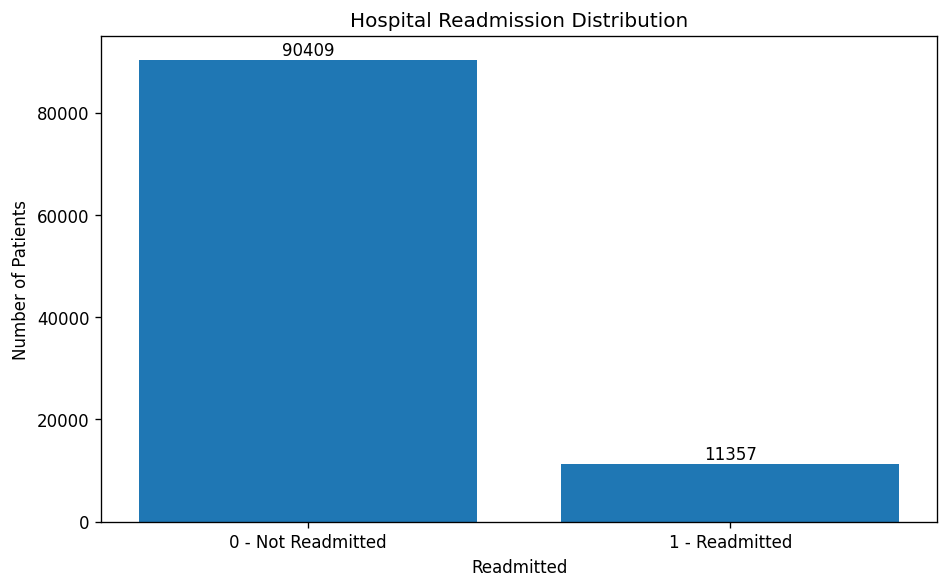

In [ ]:
# 1. Hospital Readmission Distribution

plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x="readmitted")
plt.title("Hospital Readmission Distribution")
plt.xlabel("Readmitted")
plt.ylabel("Number of Patients")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

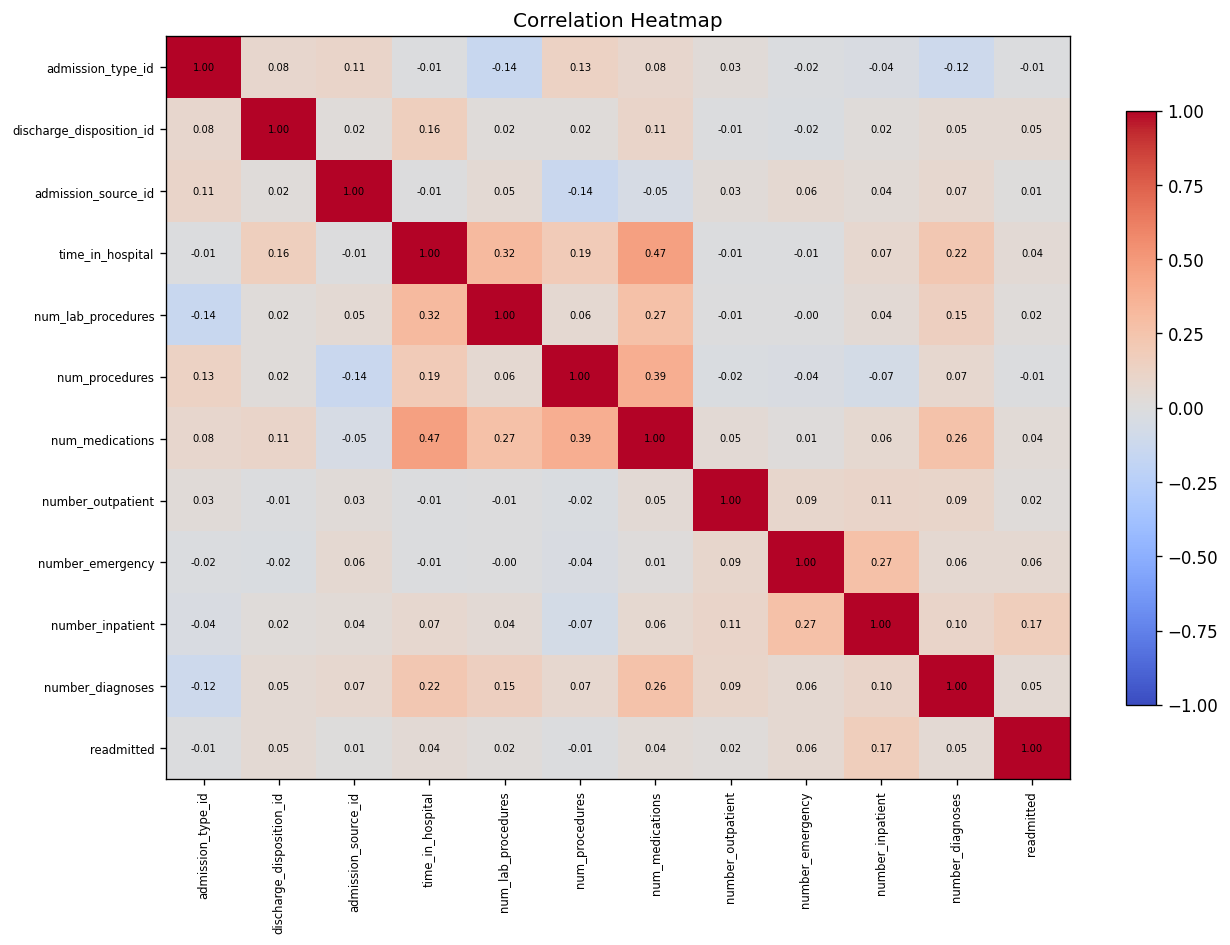

In [ ]:
# 2. Correlation Heatmap

plt.figure(figsize=(11,8))
numeric_df = df.select_dtypes(include="number")
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

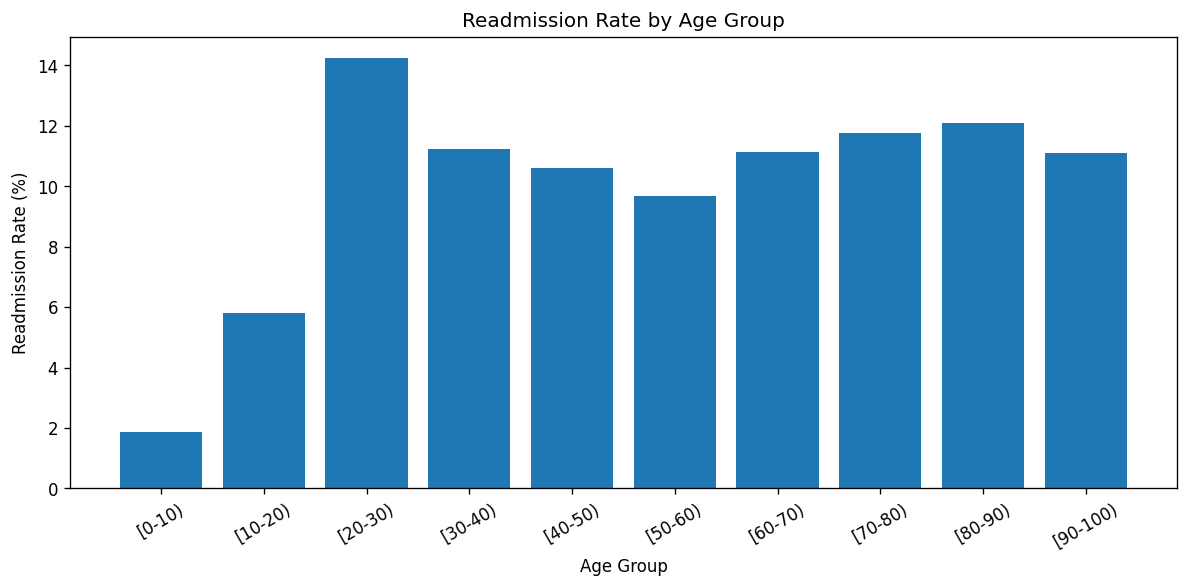

In [ ]:
# 3. Age Group vs Readmission

age_rate = df.groupby("age")["readmitted"].mean() * 100

plt.figure(figsize=(10,5))
sns.barplot(x=age_rate.index, y=age_rate.values)
plt.title("Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

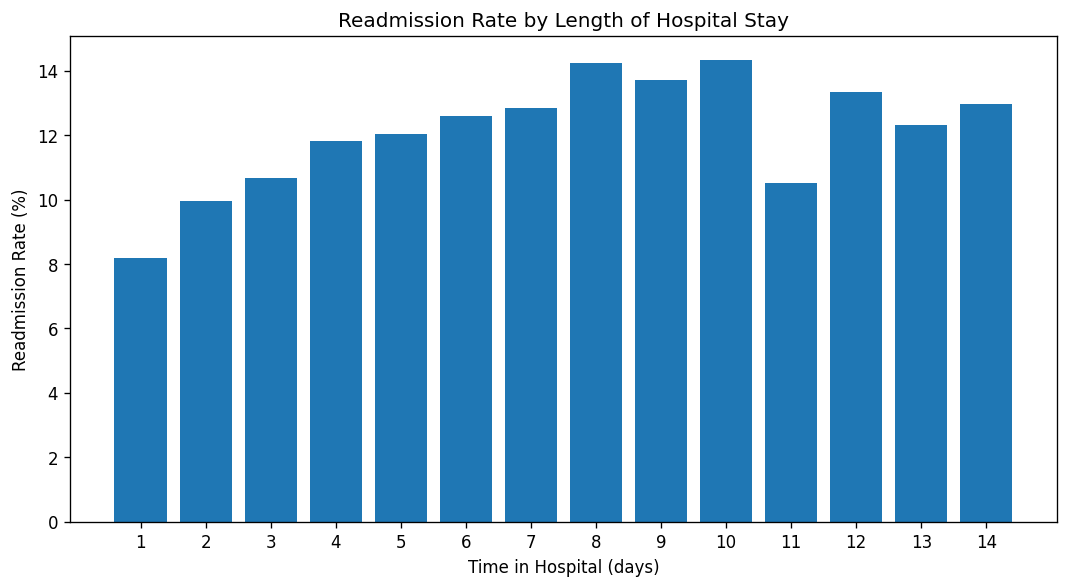

In [ ]:
# 4. Time in Hospital vs Readmission

rate = df.groupby("time_in_hospital")["readmitted"].mean() * 100

plt.figure(figsize=(9,5))
sns.barplot(x=rate.index, y=rate.values)
plt.title("Readmission Rate by Length of Hospital Stay")
plt.xlabel("Time in Hospital (days)")
plt.ylabel("Readmission Rate (%)")
plt.tight_layout()
plt.show()

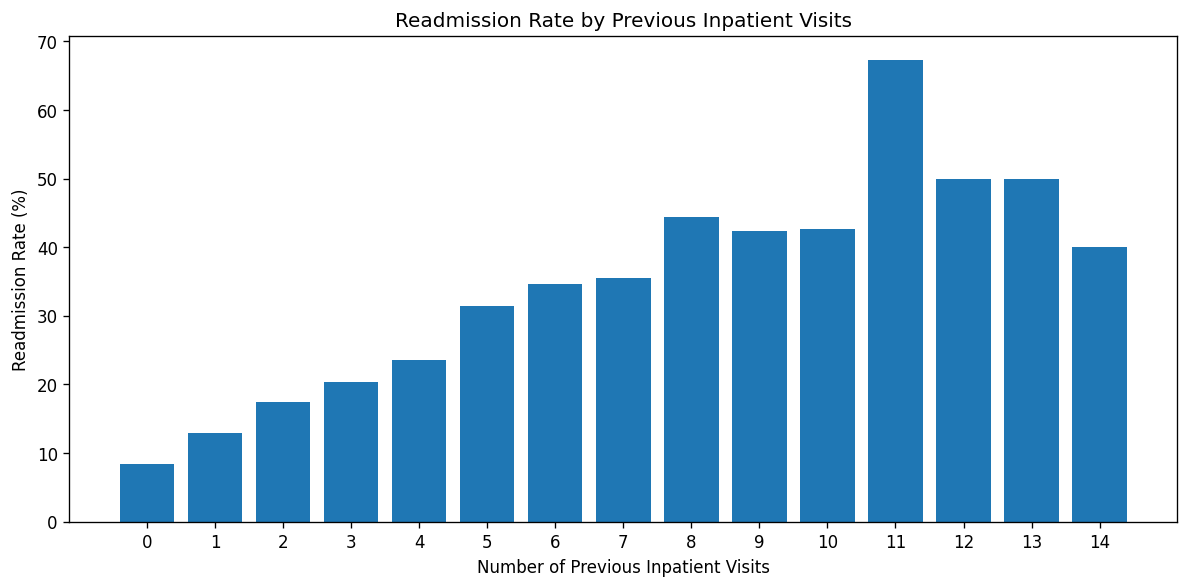

In [ ]:
# 5. Previous Inpatient Visits vs Readmission

rate = df.groupby("number_inpatient")["readmitted"].mean().head(15) * 100

plt.figure(figsize=(10,5))
sns.barplot(x=rate.index, y=rate.values)
plt.title("Readmission Rate by Previous Inpatient Visits")
plt.xlabel("Number of Previous Inpatient Visits")
plt.ylabel("Readmission Rate (%)")
plt.tight_layout()
plt.show()

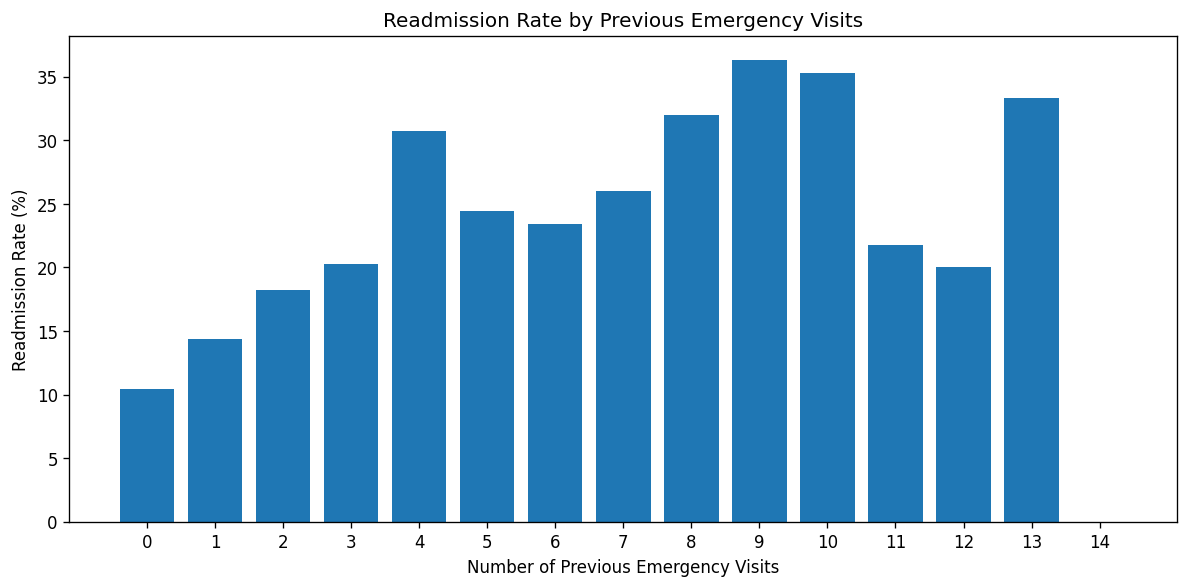

In [ ]:
# 6. Previous Emergency Visits vs Readmission

rate = df.groupby("number_emergency")["readmitted"].mean().head(15) * 100

plt.figure(figsize=(10,5))
sns.barplot(x=rate.index, y=rate.values)
plt.title("Readmission Rate by Previous Emergency Visits")
plt.xlabel("Number of Previous Emergency Visits")
plt.ylabel("Readmission Rate (%)")
plt.tight_layout()
plt.show()

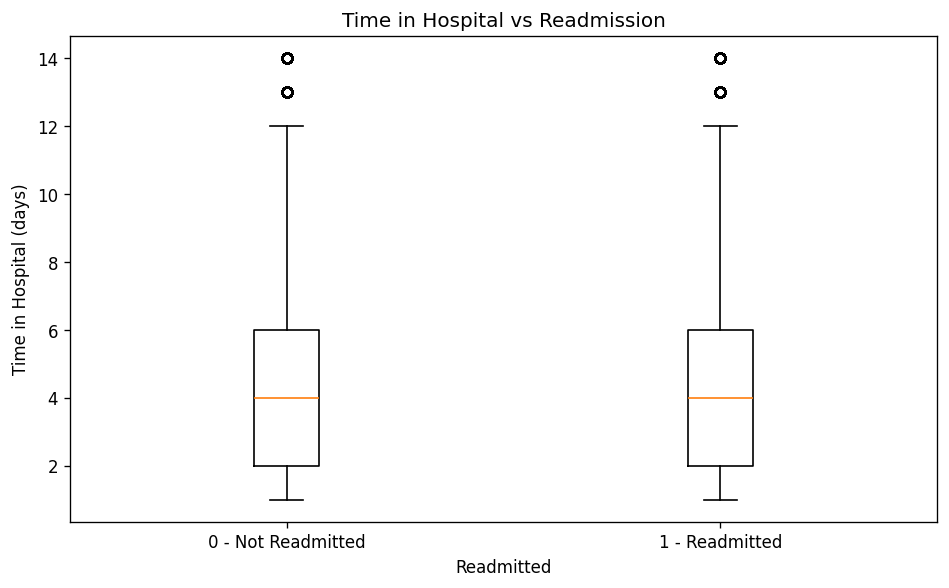

In [ ]:
# 7. Time in Hospital vs Readmission — Boxplot

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="readmitted", y="time_in_hospital")
plt.title("Time in Hospital vs Readmission")
plt.xlabel("Readmitted")
plt.ylabel("Time in Hospital (days)")
plt.tight_layout()
plt.show()

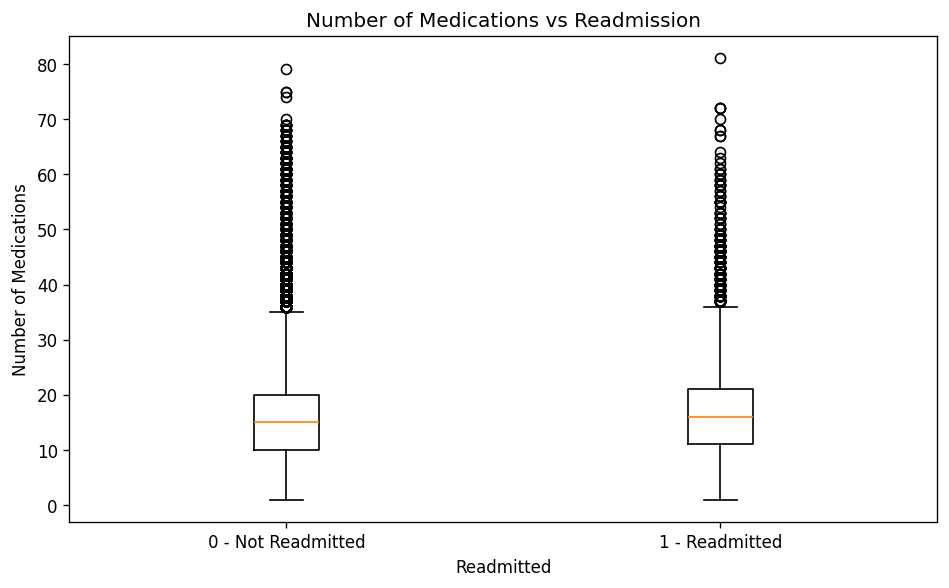

In [ ]:
# 8. Number of Medications vs Readmission — Boxplot

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="readmitted", y="num_medications")
plt.title("Number of Medications vs Readmission")
plt.xlabel("Readmitted")
plt.ylabel("Number of Medications")
plt.tight_layout()
plt.show()

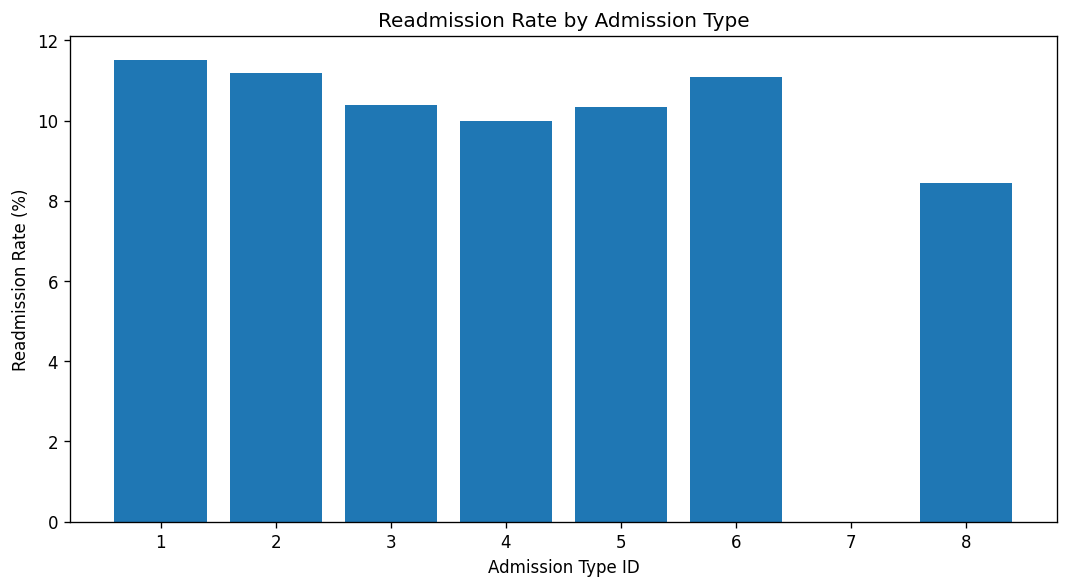

In [ ]:
# 9. Admission Type vs Readmission

rate = df.groupby("admission_type_id")["readmitted"].mean() * 100

plt.figure(figsize=(9,5))
sns.barplot(x=rate.index, y=rate.values)
plt.title("Readmission Rate by Admission Type")
plt.xlabel("Admission Type ID")
plt.ylabel("Readmission Rate (%)")
plt.tight_layout()
plt.show()

In [ ]:
# 10. Model Comparison — generated after model training

# Run this cell AFTER the Logistic Regression and Elastic Net cells.
# It uses the actual test-set metrics calculated by the notebook.

comparison = pd.DataFrame([baseline_results, elastic_results])

comparison_plot = comparison.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12,6))
sns.barplot(data=comparison_plot, x="Metric", y="Score", hue="Model")
plt.title("Model Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [ ]:
# 11. Elastic Net Confusion Matrix

cm = confusion_matrix(y_test, elastic_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Readmitted", "Readmitted"],
    yticklabels=["Not Readmitted", "Readmitted"]
)
plt.title("Elastic Net Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()


In [ ]:
# 12. ROC Curve — Logistic Regression vs Elastic Net

baseline_fpr, baseline_tpr, _ = roc_curve(y_test, baseline_prob)
elastic_fpr, elastic_tpr, _ = roc_curve(y_test, elastic_prob)

plt.figure(figsize=(8,6))
plt.plot(
    baseline_fpr, baseline_tpr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, baseline_prob):.3f})"
)
plt.plot(
    elastic_fpr, elastic_tpr,
    label=f"Elastic Net (AUC = {roc_auc_score(y_test, elastic_prob):.3f})"
)
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# 13. Elastic Net Feature Coefficients

top_positive = coef_df.sort_values("Coefficient", ascending=False).head(10)
top_negative = coef_df.sort_values("Coefficient", ascending=True).head(10)
top_features_plot = pd.concat([top_negative, top_positive]).sort_values("Coefficient")

plt.figure(figsize=(10,8))
sns.barplot(
    data=top_features_plot,
    x="Coefficient",
    y="Feature",
    hue="Feature",
    legend=False
)
plt.title("Top Elastic Net Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 14. Preprocessing for Machine Learning

The cleaned dataset contains both numerical and categorical variables.

- Numerical variables → StandardScaler
- Categorical variables → OneHotEncoder
- Unknown categories in test/new data → ignored
- The target `readmitted` is excluded from the feature matrix

In [ ]:
# Ensure target is numeric and binary
df[target] = pd.to_numeric(df[target], errors="coerce")

# Remove rows with an invalid/missing target, if any
df = df.dropna(subset=[target]).copy()
df[target] = df[target].astype(int)

X = df.drop(columns=[target])
y = df[target]

numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

In [ ]:
# Use a sparse-compatible scaler because one-hot encoding produces a sparse matrix.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created successfully.")

## 15. Train-Test Split

A stratified split is used so that the readmitted/non-readmitted class proportions are preserved in both sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).mul(100).rename("Percentage"))

print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True).mul(100).rename("Percentage"))

## 16. Baseline Logistic Regression

A standard Logistic Regression model is trained first so that its performance can be compared with the Elastic Net model.

In [ ]:
baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

baseline_pipeline.fit(X_train, y_train)

baseline_pred = baseline_pipeline.predict(X_test)
baseline_prob = baseline_pipeline.predict_proba(X_test)[:, 1]

baseline_results = {
    "Model": "Logistic Regression (L2)",
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred, zero_division=0),
    "Recall": recall_score(y_test, baseline_pred, zero_division=0),
    "F1_Score": f1_score(y_test, baseline_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, baseline_prob)
}

display(pd.DataFrame([baseline_results]).round(4))

## 17. Elastic Net Regularized Logistic Regression

Elastic Net combines:

- **L1 regularization** → encourages sparse coefficients and feature selection
- **L2 regularization** → stabilizes coefficients and helps with correlated features

In scikit-learn, Elastic Net Logistic Regression is implemented using:

`penalty="elasticnet"` and `solver="saga"`

The two main parameters tuned here are:

- `C` → inverse regularization strength
- `l1_ratio` → balance between L1 and L2 regularization

In [ ]:
elastic_net_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

print("Elastic Net pipeline created.")

## 18. Hyperparameter Tuning

GridSearchCV is used with stratified cross-validation.

The primary optimization metric is **ROC-AUC**, which is useful for evaluating a binary classifier beyond simple accuracy, especially when the classes are imbalanced.

In [ ]:
param_grid = {
    "model__C": [0.01, 0.1, 1.0, 10.0],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=elastic_net_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(round(grid_search.best_score_, 4))

## 19. Final Elastic Net Model

In [ ]:
best_elastic_net = grid_search.best_estimator_

elastic_pred = best_elastic_net.predict(X_test)
elastic_prob = best_elastic_net.predict_proba(X_test)[:, 1]

elastic_results = {
    "Model": "Elastic Net Logistic Regression",
    "Accuracy": accuracy_score(y_test, elastic_pred),
    "Precision": precision_score(y_test, elastic_pred, zero_division=0),
    "Recall": recall_score(y_test, elastic_pred, zero_division=0),
    "F1_Score": f1_score(y_test, elastic_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, elastic_prob)
}

display(pd.DataFrame([elastic_results]).round(4))

## 20. Model Comparison

In [ ]:
results_df = pd.DataFrame([baseline_results, elastic_results])

print("=" * 70)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)

display(results_df.round(4))

In [ ]:
metric_columns = ["Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC"]

results_long = results_df.melt(
    id_vars="Model",
    value_vars=metric_columns,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=results_long, x="Metric", y="Score", hue="Model")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.tight_layout()
plt.show()

## 21. Classification Report

In [ ]:
print("ELASTIC NET CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(
    y_test,
    elastic_pred,
    target_names=["Not Readmitted", "Readmitted"],
    digits=4,
    zero_division=0
))

## 22. Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, elastic_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Readmitted", "Readmitted"],
    yticklabels=["Not Readmitted", "Readmitted"]
)
plt.title("Elastic Net Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

## 23. ROC Curve

In [ ]:
baseline_fpr, baseline_tpr, _ = roc_curve(y_test, baseline_prob)
elastic_fpr, elastic_tpr, _ = roc_curve(y_test, elastic_prob)

plt.figure(figsize=(8, 6))
plt.plot(
    baseline_fpr,
    baseline_tpr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, baseline_prob):.3f})"
)
plt.plot(
    elastic_fpr,
    elastic_tpr,
    label=f"Elastic Net (AUC = {roc_auc_score(y_test, elastic_prob):.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 24. Precision-Recall Curve

In [ ]:
precision_base, recall_base, _ = precision_recall_curve(y_test, baseline_prob)
precision_elastic, recall_elastic, _ = precision_recall_curve(y_test, elastic_prob)

ap_base = average_precision_score(y_test, baseline_prob)
ap_elastic = average_precision_score(y_test, elastic_prob)

plt.figure(figsize=(8, 6))
plt.plot(
    recall_base,
    precision_base,
    label=f"Logistic Regression (AP = {ap_base:.3f})"
)
plt.plot(
    recall_elastic,
    precision_elastic,
    label=f"Elastic Net (AP = {ap_elastic:.3f})"
)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

## 25. Elastic Net Feature Analysis

The coefficients show how the trained model uses the transformed features.

- Positive coefficient → increases the model's log-odds toward readmission.
- Negative coefficient → decreases the model's log-odds toward readmission.
- Coefficients close to zero have less influence in the fitted linear decision function.

These are **model associations**, not medical causal conclusions.

In [ ]:
# Get transformed feature names
fitted_preprocessor = best_elastic_net.named_steps["preprocessor"]
elastic_model = best_elastic_net.named_steps["model"]

try:
    feature_names = fitted_preprocessor.get_feature_names_out()
except Exception:
    # Fallback for older scikit-learn versions
    feature_names = np.array(
        [f"feature_{i}" for i in range(len(elastic_model.coef_[0]))]
    )

coefficients = elastic_model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Absolute_Coefficient", ascending=False)

print("Top 20 features by absolute Elastic Net coefficient:")
display(coef_df.head(20))

## 26. Positive and Negative Feature Coefficients

In [ ]:
top_positive = coef_df.sort_values("Coefficient", ascending=False).head(10)
top_negative = coef_df.sort_values("Coefficient", ascending=True).head(10)

print("Top positive coefficients:")
display(top_positive[["Feature", "Coefficient"]])

print("\nTop negative coefficients:")
display(top_negative[["Feature", "Coefficient"]])

In [ ]:
top_features_plot = pd.concat([
    top_positive.assign(Direction="Positive"),
    top_negative.assign(Direction="Negative")
]).sort_values("Coefficient")

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_features_plot,
    x="Coefficient",
    y="Feature",
    hue="Direction",
    dodge=False
)
plt.title("Top Elastic Net Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 27. Number of Coefficients Shrunk to Zero

One of the useful properties of the L1 component of Elastic Net is that some coefficients can become exactly zero, effectively removing those transformed features from the linear model.

In [ ]:
zero_coefficients = int(np.sum(np.isclose(coefficients, 0)))
total_coefficients = len(coefficients)

print("Total transformed features:", total_coefficients)
print("Coefficients equal to zero:", zero_coefficients)
print(
    "Percentage of coefficients equal to zero:",
    round((zero_coefficients / total_coefficients) * 100, 2),
    "%"
)

## 28. Final Patient Prediction Function

This function accepts a single patient record using the same feature names as the training data.

It returns:

- predicted class
- probability of readmission
- probability of no readmission

**Important:** This is a machine-learning demonstration and is not a clinical diagnostic tool.

In [ ]:
def predict_readmission(patient_data):
    patient_df = pd.DataFrame([patient_data])

    missing_features = [c for c in X.columns if c not in patient_df.columns]
    extra_features = [c for c in patient_df.columns if c not in X.columns]

    if missing_features:
        raise ValueError(
            "Missing required features: " + ", ".join(missing_features)
        )

    patient_df = patient_df[X.columns]

    probability = best_elastic_net.predict_proba(patient_df)[0, 1]
    prediction = int(probability >= 0.5)

    return {
        "Prediction": prediction,
        "Prediction_Label": "Readmitted" if prediction == 1 else "Not Readmitted",
        "Readmission_Probability": round(float(probability), 4),
        "No_Readmission_Probability": round(float(1 - probability), 4)
    }

print("Prediction function created successfully.")

## 29. Example Patient Prediction

The following example uses the first patient in the test set so that all required feature names and valid category values are guaranteed to match the trained model.

In [ ]:
example_patient = X_test.iloc[0].to_dict()

prediction_result = predict_readmission(example_patient)

print("=" * 60)
print("EXAMPLE PATIENT PREDICTION")
print("=" * 60)
for key, value in prediction_result.items():
    print(f"{key}: {value}")

## 30. Save the Trained Model

The fitted Elastic Net pipeline contains both preprocessing and the trained model, so it can be saved as one object.

In [ ]:
import joblib

model_filename = "hospital_readmission_elastic_net_model.pkl"
joblib.dump(best_elastic_net, model_filename)

print("Saved model:", model_filename)

## 31. Final Project Summary

In [ ]:
best_row = results_df.loc[results_df["ROC_AUC"].idxmax()]

print("=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)

print("Project: Hospital Readmission Prediction")
print("Target: readmitted")
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nBest Elastic Net parameters:")
print(grid_search.best_params_)

print("\nElastic Net test performance:")
print(f"Accuracy : {elastic_results['Accuracy']:.4f}")
print(f"Precision: {elastic_results['Precision']:.4f}")
print(f"Recall   : {elastic_results['Recall']:.4f}")
print(f"F1 Score : {elastic_results['F1_Score']:.4f}")
print(f"ROC-AUC  : {elastic_results['ROC_AUC']:.4f}")

print("\nTop 10 model features by absolute coefficient:")
display(coef_df.head(10)[["Feature", "Coefficient"]])

print("\nNotebook execution completed successfully.")

## Conclusion

This notebook implements a complete machine-learning workflow for hospital readmission prediction using **Elastic Net Regularized Logistic Regression**.

The workflow includes:

1. Dataset loading
2. Data quality analysis
3. Statistical analysis
4. Exploratory Data Analysis
5. Numerical and categorical feature handling
6. Train-test splitting
7. Baseline Logistic Regression
8. Elastic Net Logistic Regression
9. Hyperparameter tuning of `C` and `l1_ratio`
10. Accuracy, Precision, Recall, F1-score and ROC-AUC evaluation
11. Confusion matrix
12. ROC and Precision-Recall curves
13. Feature coefficient analysis
14. Final patient prediction
15. Model saving

**Note:** Model predictions are for the academic machine-learning project and should not be interpreted as clinical diagnoses or treatment recommendations.